#  Parallel (and Vectorized) Matrix Multiplication

**Author:** Juan Diego González Noguera  
**Date:** December 2024  
**System:** AMD Ryzen 5 7520U (4 cores, 8 threads), Windows 11 and 16 GB of RAM

## 1. Import Libraries and Load Data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visualization configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Figure size
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded")

✓ Libraries loaded


In [67]:
# Search for the most recent CSV file
csv_files = sorted(Path('.').glob('benchmark_results.csv'), reverse=True)

if csv_files:
    csv_file = str(csv_files[0])
    print(f"📁 Loading: {csv_file}")
else:
    # Or specify the file manually
    csv_file = 'benchmark_results.csv'
    print(f"📁 Trying to load: {csv_file}")

# Load data
df = pd.read_csv(csv_file)
df = df[df['success'] == True]  # Only successful results

print(f"\n✓ Data loaded: {len(df)} records")
print(f"  Sizes: {sorted(df['size'].unique())}")
print(f"  Methods: {len(df['method'].unique())}")

df.head()

📁 Loading: benchmark_results.csv

✓ Data loaded: 39 records
  Sizes: [100, 200, 500, 1000]
  Methods: 10


,method,execution_time,memory_used,success,size,threads,processes
0,Basic (sequential),0.574589,0.074219,True,100,1.0,1.0
1,Threading (2 threads),0.578454,0.007812,True,100,2.0,NaN
2,Threading (4 threads),0.561546,0.097656,True,100,4.0,NaN
3,Threading (8 threads),0.570510,0.007812,True,100,8.0,NaN
4,Multiprocessing (2 processes),1.802104,1.101562,True,100,NaN,2.0


## 2. Initial Data Exploration

In [51]:
# Descriptive statistics
print("📊 Execution Time Statistics:")
print(df['execution_time'].describe())

print("\n📊 Memory Statistics:")
print(df['memory_used'].describe())

📊 Execution Time Statistics:
count     39.000000
mean      77.629141
std      168.723997
min        0.000626
25%        0.506815
50%        3.266519
75%       55.968488
max      586.525938
Name: execution_time, dtype: float64

📊 Memory Statistics:
count    39.000000
mean      3.544972
std      10.375577
min       0.000000
25%       0.041016
50%       1.101562
75%       2.029297
max      64.535156
Name: memory_used, dtype: float64


In [52]:
# Summary by method
summary = df.groupby('method').agg({
    'execution_time': ['mean', 'std', 'min', 'max'],
    'memory_used': ['mean', 'max']
}).round(4)

print("📊 Summary by Method:")
summary

📊 Summary by Method:


execution_time                              \
                                        mean       std     min       max   
method                                                                     
Basic (sequential)                   23.7396   36.8769  0.5746   66.2647   
Multiprocessing (2 processes)       121.8107  210.2359  1.8021  435.7098   
Multiprocessing (4 processes)        70.6007  118.0625  1.9290  246.5800   
Multiprocessing (8 processes)        56.3716   92.1063  2.8865  193.6512   
NumPy (vectorized + parallel)         0.0111    0.0144  0.0006    0.0321   
Numba parallel (JIT + prange)         0.2814    0.3134  0.0011    0.6370   
Numba vectorized (JIT + dot)          0.5204    0.7562  0.0131    1.6447   
Threading (2 threads)               161.3906  275.0166  0.5785  571.2275   
Threading (4 threads)               163.2152  279.4214  0.5615  579.7779   
Threading (8 threads)               164.8778  282.7884  0.5705  586.5259   

                              memory_used           
                                     mean      max  
method                                              
Basic (sequential)                 0.7435   1.8516  
Multiprocessing (2 processes)      1.3965   2.6484  
Multiprocessing (4 processes)      0.5977   1.9141  
Multiprocessing (8 processes)      0.9990   2.0195  
NumPy (vectorized + parallel)      3.2822   9.6406  
Numba parallel (JIT + prange)     18.5723  64.5352  
Numba vectorized (JIT + dot)       4.2715   7.6836  
Threading (2 threads)              1.8945   5.6992  
Threading (4 threads)              2.4697   7.7578  
Threading (8 threads)              0.5225   2.0391

## 3. Calculate Metrics: Speedup and Efficiency

In [53]:
# Calculate speedup
df['speedup'] = np.nan

for size in df['size'].unique():
    size_mask = df['size'] == size
    size_data = df[size_mask]
    
    # Baseline: basic method or the slowest
    baseline = size_data[size_data['method'] == 'Basic (sequential)']
    if not baseline.empty:
        baseline_time = baseline['execution_time'].values[0]
    else:
        baseline_time = size_data['execution_time'].max()
    
    df.loc[size_mask, 'speedup'] = baseline_time / df.loc[size_mask, 'execution_time']

print("✓ Speedup calculated")

# Calculate efficiency
df['efficiency'] = np.nan

# Threading
threading_mask = df['method'].str.contains('Threading', na=False)
if 'threads' in df.columns:
    df.loc[threading_mask, 'efficiency'] = df.loc[threading_mask, 'speedup'] / df.loc[threading_mask, 'threads']

# Multiprocessing
mp_mask = df['method'].str.contains('Multiprocessing', na=False)
if 'processes' in df.columns:
    df.loc[mp_mask, 'efficiency'] = df.loc[mp_mask, 'speedup'] / df.loc[mp_mask, 'processes']

print("✓ Efficiency calculated")

# Show table with metrics
df[['method', 'size', 'execution_time', 'speedup', 'efficiency']].head(15)

✓ Speedup calculated
✓ Efficiency calculated


,method,size,execution_time,speedup,efficiency
0,Basic (sequential),100,0.574589,1.000000,NaN
1,Threading (2 threads),100,0.578454,0.993318,0.496659
2,Threading (4 threads),100,0.561546,1.023227,0.255807
3,Threading (8 threads),100,0.570510,1.007150,0.125894
4,Multiprocessing (2 processes),100,1.802104,0.318843,0.159422
5,Multiprocessing (4 processes),100,1.929020,0.297866,0.074466
6,Multiprocessing (8 processes),100,2.886534,0.199058,0.024882
7,NumPy (vectorized + parallel),100,0.008105,70.894865,NaN
8,Numba parallel (JIT + prange),100,0.637000,0.902022,NaN
9,Numba vectorized (JIT + dot),100,0.255185,2.251657,NaN


## 4. Visualizations

### 4.1 Execution Time vs Size

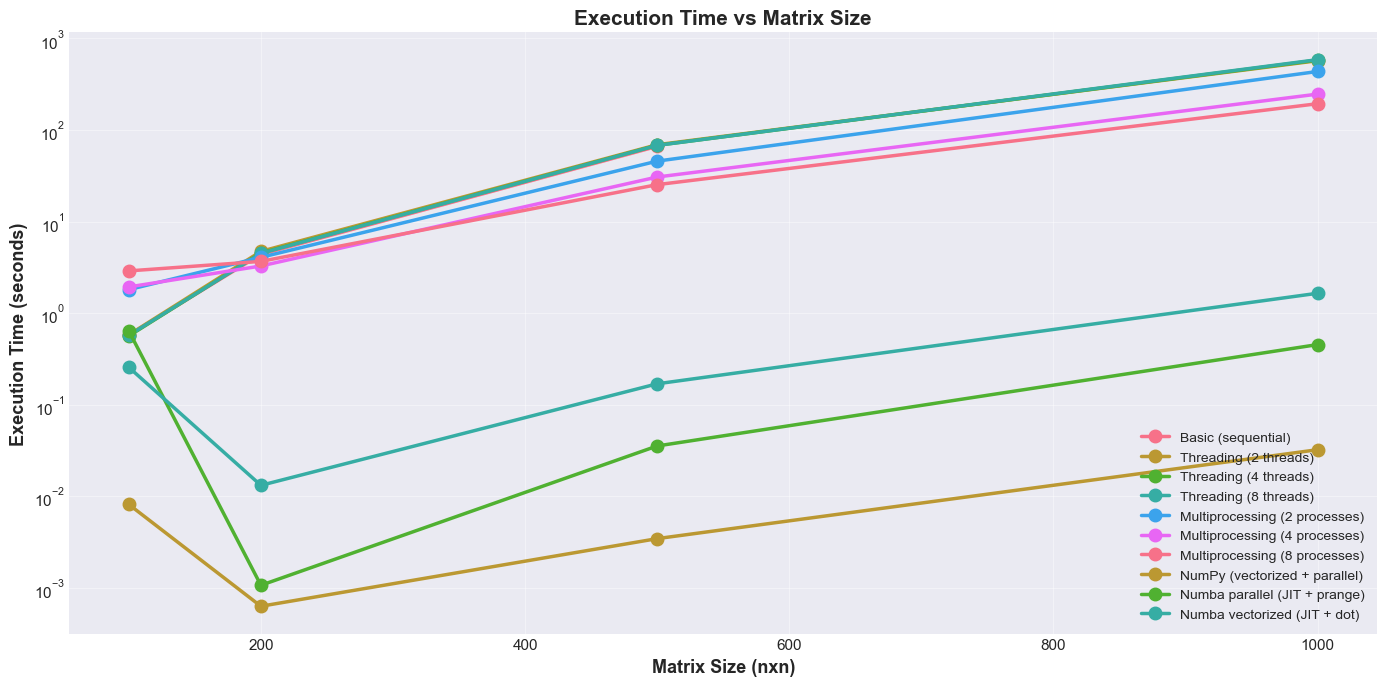

In [54]:
plt.figure(figsize=(14, 7))

for method in df['method'].unique():
    method_data = df[df['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['execution_time'],
            marker='o', linewidth=2.5, markersize=9, label=method)

plt.xlabel('Matrix Size (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Execution Time (seconds)', fontsize=13, fontweight='bold')
plt.title('Execution Time vs Matrix Size', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 4.2 Speedup vs Size

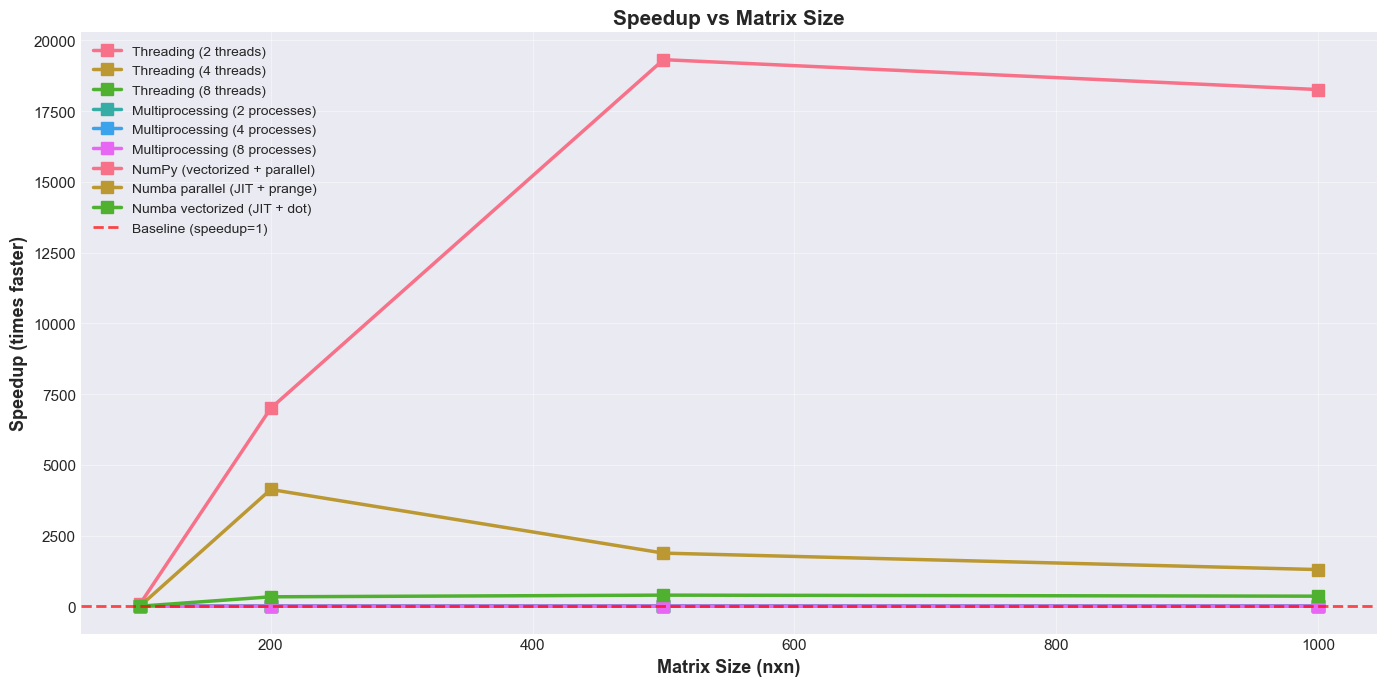

In [55]:
plt.figure(figsize=(14, 7))

# Exclude basic method
df_speedup = df[df['method'] != 'Basic (sequential)'].copy()

for method in df_speedup['method'].unique():
    method_data = df_speedup[df_speedup['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['speedup'],
            marker='s', linewidth=2.5, markersize=9, label=method)

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Baseline (speedup=1)')

plt.xlabel('Matrix Size (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Speedup (times faster)', fontsize=13, fontweight='bold')
plt.title('Speedup vs Matrix Size', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 4.3 Methods Comparison (Last Size)

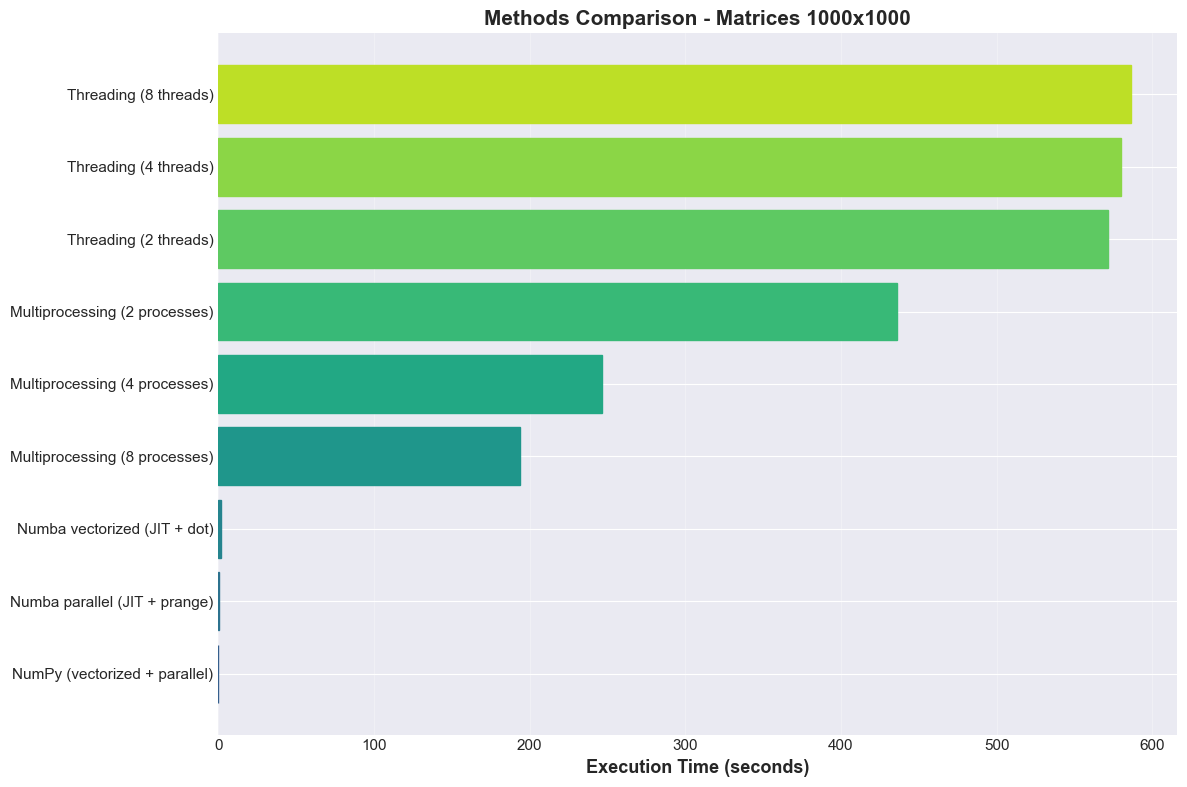


🏆 Fastest method for 1000x1000:
   NumPy (vectorized + parallel): 0.0321s


In [56]:
# Get the largest size
max_size = df['size'].max()
df_max = df[df['size'] == max_size].sort_values('execution_time')

plt.figure(figsize=(12, 8))
bars = plt.barh(df_max['method'], df_max['execution_time'])

# Color bars
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Execution Time (seconds)', fontsize=13, fontweight='bold')
plt.title(f'Methods Comparison - Matrices {max_size}x{max_size}', 
         fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n🏆 Fastest method for {max_size}x{max_size}:")
print(f"   {df_max.iloc[0]['method']}: {df_max.iloc[0]['execution_time']:.4f}s")

### 4.4 Time Heatmap

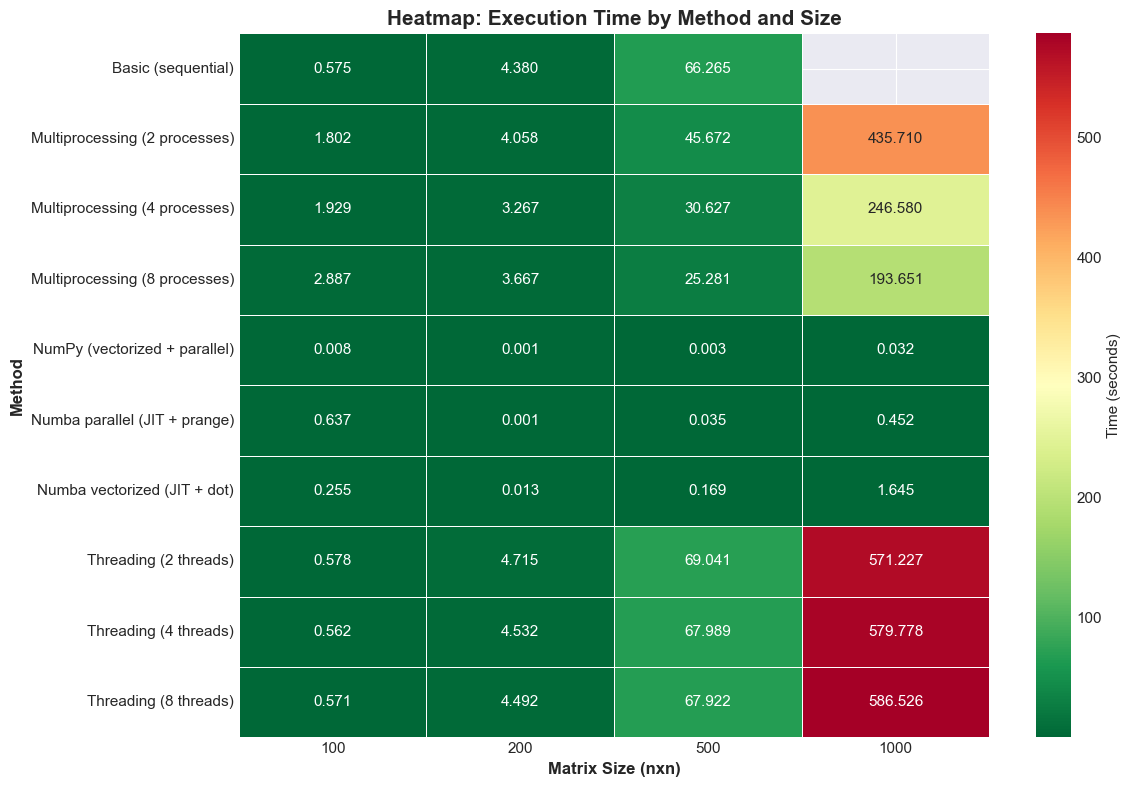

In [57]:
# Create pivot table
pivot = df.pivot_table(values='execution_time', index='method', columns='size', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', 
           cbar_kws={'label': 'Time (seconds)'}, linewidths=0.5)
plt.title('Heatmap: Execution Time by Method and Size', 
         fontsize=15, fontweight='bold')
plt.xlabel('Matrix Size (nxn)', fontsize=12, fontweight='bold')
plt.ylabel('Method', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Parallelization Efficiency

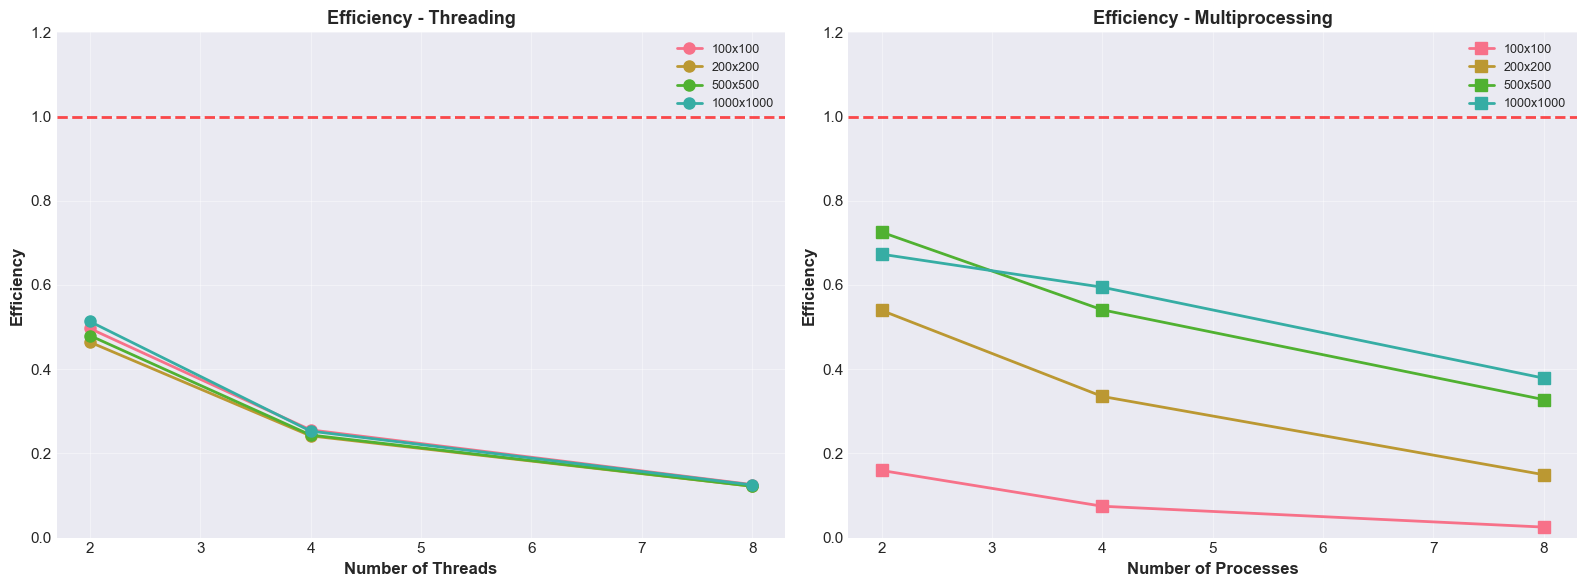

In [58]:
# Filter efficiency data
df_eff = df[df['efficiency'].notna()].copy()

if not df_eff.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Threading
    threading = df_eff[df_eff['method'].str.contains('Threading', na=False)]
    if not threading.empty:
        for size in sorted(threading['size'].unique()):
            size_data = threading[threading['size'] == size].sort_values('threads')
            axes[0].plot(size_data['threads'], size_data['efficiency'],
                       marker='o', linewidth=2, markersize=8, label=f'{size}x{size}')
        
        axes[0].axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
        axes[0].set_xlabel('Number of Threads', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Efficiency', fontsize=12, fontweight='bold')
        axes[0].set_title('Efficiency - Threading', fontsize=13, fontweight='bold')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.4)
        axes[0].set_ylim(0, 1.2)
    
    # Multiprocessing
    mp = df_eff[df_eff['method'].str.contains('Multiprocessing', na=False)]
    if not mp.empty:
        for size in sorted(mp['size'].unique()):
            size_data = mp[mp['size'] == size].sort_values('processes')
            axes[1].plot(size_data['processes'], size_data['efficiency'],
                       marker='s', linewidth=2, markersize=8, label=f'{size}x{size}')
        
        axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
        axes[1].set_xlabel('Number of Processes', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Efficiency', fontsize=12, fontweight='bold')
        axes[1].set_title('Efficiency - Multiprocessing', fontsize=13, fontweight='bold')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.4)
        axes[1].set_ylim(0, 1.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No efficiency data available")

### 4.6 Memory Usage

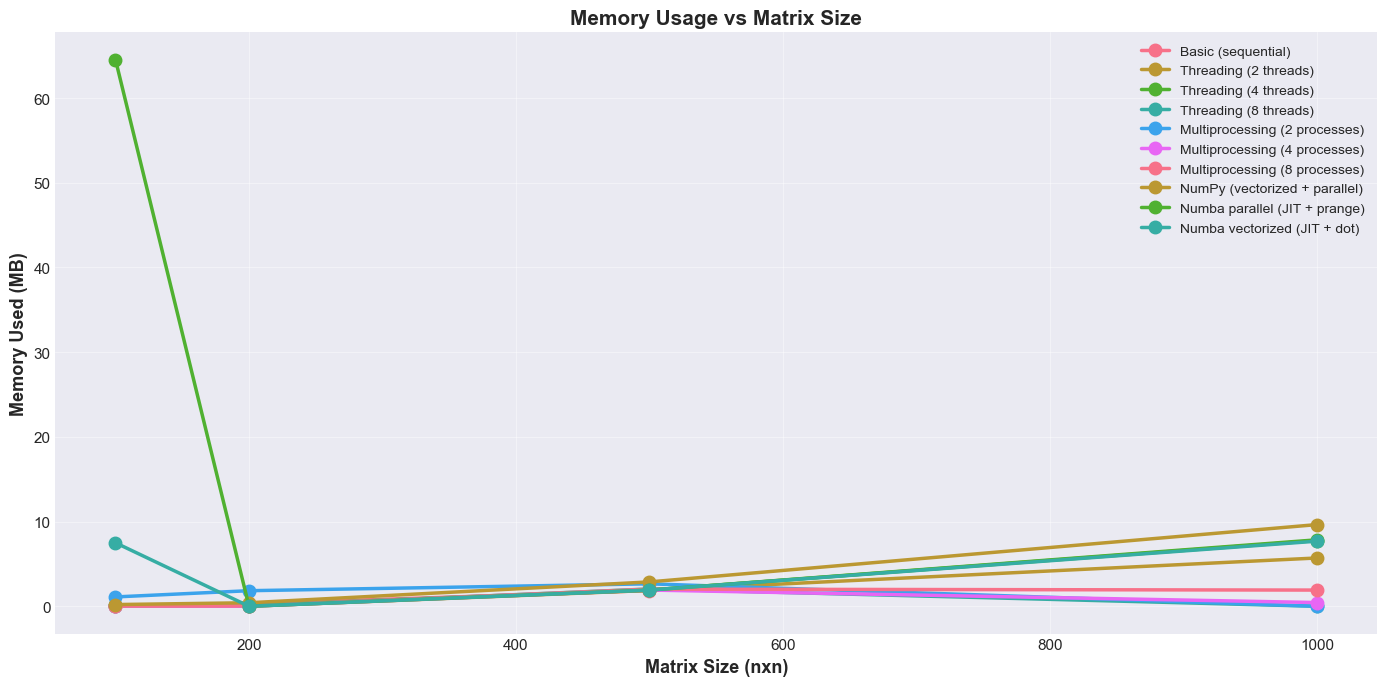

In [59]:
plt.figure(figsize=(14, 7))

for method in df['method'].unique():
    method_data = df[df['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['memory_used'],
            marker='o', linewidth=2.5, markersize=9, label=method)

plt.xlabel('Matrix Size (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Memory Used (MB)', fontsize=13, fontweight='bold')
plt.title('Memory Usage vs Matrix Size', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Statistical Analysis

In [61]:
print("📊 TOP 5 FASTEST METHODS (Average):")
print("="*60)

avg_times = df.groupby('method')['execution_time'].mean().sort_values()
for i, (method, time) in enumerate(avg_times.head().items(), 1):
    print(f"{i}. {method:45s}: {time:8.4f}s")

print(f"\n🏆 WINNER: {avg_times.index[0]}")
print(f"   Average time: {avg_times.values[0]:.4f}s")

📊 TOP 5 FASTEST METHODS (Average):
1. NumPy (vectorized + parallel)                :   0.0111s
2. Numba parallel (JIT + prange)                :   0.2814s
3. Numba vectorized (JIT + dot)                 :   0.5204s
4. Basic (sequential)                           :  23.7396s
5. Multiprocessing (8 processes)                :  56.3716s

🏆 WINNER: NumPy (vectorized + parallel)
   Average time: 0.0111s


In [62]:
print("📊 BEST SPEEDUP ACHIEVED:")
print("="*60)

if 'speedup' in df.columns and df['speedup'].notna().any():
    best_speedup = df.loc[df['speedup'].idxmax()]
    print(f"Method: {best_speedup['method']}")
    print(f"Size: {best_speedup['size']}x{best_speedup['size']}")
    print(f"Speedup: {best_speedup['speedup']:.2f}x")
    print(f"Time: {best_speedup['execution_time']:.4f}s")

📊 BEST SPEEDUP ACHIEVED:
Method: NumPy (vectorized + parallel)
Size: 500x500
Speedup: 19321.41x
Time: 0.0034s


In [63]:
print("📊 THREADING vs MULTIPROCESSING COMPARISON:")
print("="*60)

threading_avg = df[df['method'].str.contains('Threading', na=False)]['execution_time'].mean()
mp_avg = df[df['method'].str.contains('Multiprocessing', na=False)]['execution_time'].mean()

print(f"Threading (average):      {threading_avg:.4f}s")
print(f"Multiprocessing (average): {mp_avg:.4f}s")
print(f"\nMultiprocessing is {threading_avg/mp_avg:.2f}x faster than Threading")

📊 THREADING vs MULTIPROCESSING COMPARISON:
Threading (average):      163.1612s
Multiprocessing (average): 82.9277s

Multiprocessing is 1.97x faster than Threading


## 6. Export Results

In [64]:
# Save processed DataFrame
df.to_csv('benchmark_results_processed.csv', index=False)
print("✓ Processed results saved to: benchmark_results_processed.csv")

# Save summary
summary_df = df.groupby(['method', 'size']).agg({
    'execution_time': 'mean',
    'speedup': 'mean',
    'efficiency': 'mean',
    'memory_used': 'mean'
}).round(4)

summary_df.to_csv('benchmark_summary.csv')
print("✓ Summary saved to: benchmark_summary.csv")

✓ Processed results saved to: benchmark_results_processed.csv
✓ Summary saved to: benchmark_summary.csv
